<a href="https://colab.research.google.com/github/oleg61/DataScient/blob/Learn_AI/%D0%A2%D0%B5%D0%BC%D0%B0%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%BE%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B8%D1%80%D0%BE%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_%D0%92%D0%BE%D1%80%D0%BE%D0%BF%D0%B0%D0%B5%D0%B2_%D0%9E%D0%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание по NLP #1 — классификация по тональности

Отзывы на банки с сайта banki.ru. Оценка по шкале от 1 до 5.

Данные: `banki_responses.json.bz2` на Google Drive (`DATA_DIR`).


In [ ]:
# Подключение Google Drive (Colab) и базовые импорты
from pathlib import Path

try:
    from google.colab import drive

    drive.mount("/content/drive")
except ImportError:
    # Локальный запуск без Colab — Drive уже не монтируем
    pass

DATA_DIR = Path("/content/drive/MyDrive/13")


def resolve_data_path(data_dir: Path) -> Path:
    """Ищем banki_responses.json.bz2 в DATA_DIR и подпапках."""
    direct = data_dir / "banki_responses.json.bz2"
    if direct.exists():
        return direct
    found = sorted(data_dir.rglob("banki_responses.json.bz2"))
    if not found:
        raise FileNotFoundError(
            f"Не найден banki_responses.json.bz2 в {data_dir}. "
            "Положите файл на Drive или поправьте DATA_DIR."
        )
    return found[0]


DATA_PATH = resolve_data_path(DATA_DIR)
print("DATA_PATH =", DATA_PATH)


Mounted at /content/drive
DATA_PATH = /content/drive/MyDrive/13/banki_responses.json.bz2


In [ ]:
import bz2
import json
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

%matplotlib inline
sns.set_theme(style="whitegrid")


In [ ]:
def load_responses(path: Path) -> list[dict]:
    """Читаем JSONL из bz2: только проверенные отзывы с непустым текстом."""
    responses: list[dict] = []
    with bz2.BZ2File(path, "r") as thefile:
        for row in tqdm(thefile, desc="loading"):
            resp = json.loads(row)
            if resp.get("rating_not_checked"):
                continue
            text = (resp.get("text") or "").strip()
            if not text:
                continue
            responses.append(resp)
    return responses


responses = load_responses(DATA_PATH)
print(f"Загружено отзывов: {len(responses):,}")


loading: 0it [00:00, ?it/s]

Загружено отзывов: 153,499


Посмотрим на пример отзыва:

In [ ]:
responses[359]

{'city': 'г. Москва',
 'rating_not_checked': False,
 'title': 'Очень неприятный поступок',
 'num_comments': 2,
 'bank_license': 'лицензия № 2673',
 'author': 'Timkin',
 'bank_name': 'Тинькофф Банк',
 'datetime': '2015-05-29 22:44:54',
 'text': 'Ну что, такого поворота событий я конечно не ожидал. Банк в одностороннем порядке изменил условие по процентной ставке для действующих пополняемых вкладов. Пока сообщение об этом пришло по почте моей супруге, но думаю, что придет и мне, судя по опубликованной новости.\xa0 Банк до сего дня для меня обладал безупречной репутацией.\xa0По моей рекомендации клиентами банка стали множество коллег и знакомых. Конечно они принимали решения сами, но мне от этого все равно не очень приятно.\xa0Вклады безусловно открывались в надежде заработать, процентная ставка действительно на момент открытия вклада была одной из лучших на рынке. Но ведь мы же действуем по принципу Win-Win. Банку нужны деньги в непростой период - он платит клиенту за риск. Клиенту нужны

In [ ]:
df = pd.DataFrame(responses)
print(df.shape)
df.head(3)


(153499, 10)


,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
1,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
2,г. Москва,False,Двойное списание за один товар.,1,лицензия № 2562,Vladimir84,Бинбанк,2015-06-05 20:14:28,Здравствуйте! Дублирую свое заявление от 03.0...,NaN


## Часть 1. Анализ текстов

### 1. Количество отзывов в разных городах и на разные банки


In [ ]:
def top_counts(series: pd.Series, n: int = 20) -> pd.Series:
    """Топ-N значений по частоте (пропуски отбрасываем)."""
    return series.dropna().value_counts().head(n)


cities = top_counts(df["city"], 20)
banks = top_counts(df["bank_name"], 20)

print("Уникальных городов:", df["city"].nunique(dropna=True))
print("Уникальных банков:", df["bank_name"].nunique(dropna=True))
display(cities.to_frame("n_reviews"))
display(banks.to_frame("n_reviews"))


Уникальных городов: 5823
Уникальных банков: 670


,n_reviews
city,
г. Москва,55354
г. Санкт-Петербург,14342
г. Екатеринбург,2337
г. Новосибирск,2300
г. Нижний Новгород,1976
г. Ростов-на-Дону,1891
г. Самара,1731
г. Челябинск,1507
г. Казань,1440


,n_reviews
bank_name,
Сбербанк России,26327
Альфа-Банк,10224
ВТБ 24,8185
Русский Стандарт,7943
Хоум Кредит Банк,7549
Тинькофф Банк,5387
Национальный Банк «Траст»,4607
Ренессанс Кредит,3849
Связной Банк,3775


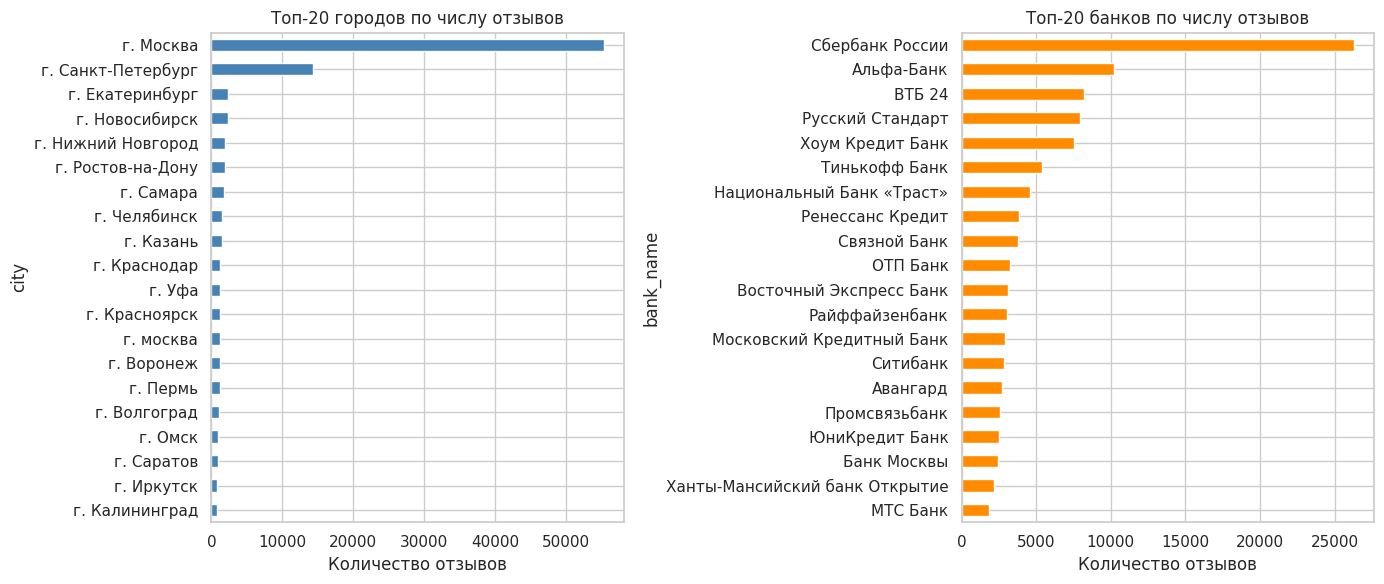

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cities.iloc[::-1].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Топ-20 городов по числу отзывов")
axes[0].set_xlabel("Количество отзывов")

banks.iloc[::-1].plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Топ-20 банков по числу отзывов")
axes[1].set_xlabel("Количество отзывов")

plt.tight_layout()
plt.show()


### 2. Гистограммы длин отзывов в символах и в словах

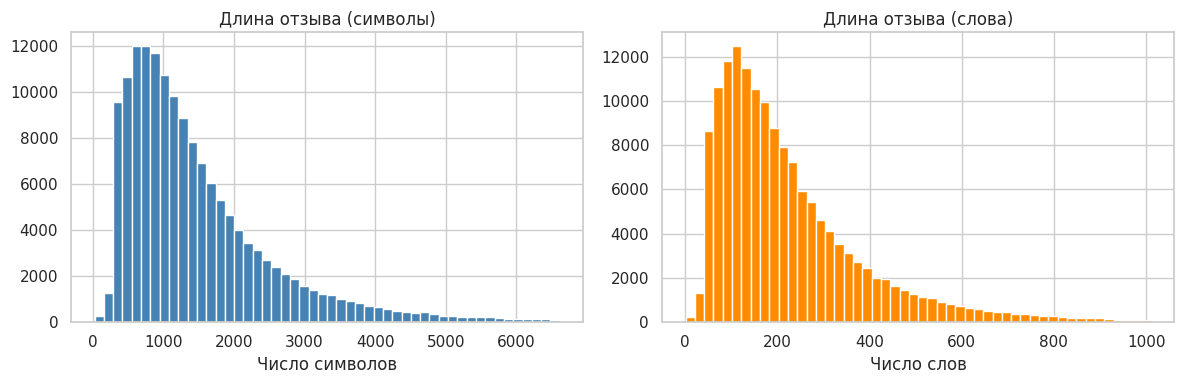

,len_chars,len_words
count,153499.000000,153499.000000
mean,1554.212790,237.062743
std,1319.098042,201.430014
min,23.000000,1.000000
25%,732.000000,111.000000
50%,1193.000000,182.000000
75%,1929.000000,295.000000
max,32082.000000,5000.000000


In [ ]:
df["len_chars"] = df["text"].str.len()
df["len_words"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Обрезаем хвост для читаемости (99-й перцентиль)
char_lim = df["len_chars"].quantile(0.99)
word_lim = df["len_words"].quantile(0.99)

axes[0].hist(df.loc[df["len_chars"] <= char_lim, "len_chars"], bins=50, color="steelblue")
axes[0].set_title("Длина отзыва (символы)")
axes[0].set_xlabel("Число символов")

axes[1].hist(df.loc[df["len_words"] <= word_lim, "len_words"], bins=50, color="darkorange")
axes[1].set_title("Длина отзыва (слова)")
axes[1].set_xlabel("Число слов")

plt.tight_layout()
plt.show()

df[["len_chars", "len_words"]].describe()


### 3. Десять самых частых: слов / без стоп-слов / лемм / существительных

Для морфологии берём подвыборку: полный корпус ~200k отзывов лемматизировать долго.


In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)
RU_STOPWORDS = set(stopwords.words("russian"))

# Дополнительные шумовые токены для отзывов
RU_STOPWORDS.update(
    {
        "это", "ещё", "еще", "очень", "просто", "также", "который", "которая",
        "которые", "весь", "всё", "все", "свой", "наш", "ваш", "мой",
    }
)

TOKEN_RE = re.compile(r"[а-яёa-z]+", re.IGNORECASE)


def tokenize(text: str) -> list[str]:
    """Нижний регистр + только буквенные токены."""
    return TOKEN_RE.findall(text.lower())


# Подвыборка для тяжёлых шагов (частоты, темы)
MORPH_SAMPLE = min(30_000, len(df))
rng = np.random.default_rng(42)
sample_idx = rng.choice(df.index, size=MORPH_SAMPLE, replace=False)
df_sample = df.loc[sample_idx].copy()
print(f"Подвыборка для морфологии/тем: {MORPH_SAMPLE:,}")


Подвыборка для морфологии/тем: 30,000


In [ ]:
# pymorphy2 сломан на Python 3.11+ (inspect.getargspec удалён).
# Ставим pymorphy3 — тот же API, совместим с текущим Colab.
import sys

!{sys.executable} -m pip install -q --upgrade pymorphy3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 63.0 MB/s eta 0:00:00


In [ ]:
import pymorphy3

morph = pymorphy3.MorphAnalyzer()


def lemmatize_tokens(tokens: list[str]) -> list[tuple[str, str]]:
    """Возвращает список (lemma, POS) для токенов."""
    result = []
    for tok in tokens:
        p = morph.parse(tok)[0]
        result.append((p.normal_form, p.tag.POS))
    return result


# Токены по всей подвыборке
all_tokens: list[str] = []
all_lemmas: list[str] = []
all_nouns: list[str] = []

for text in tqdm(df_sample["text"], desc="tokenize+morph"):
    tokens = tokenize(text)
    all_tokens.extend(tokens)
    for lemma, pos in lemmatize_tokens(tokens):
        all_lemmas.append(lemma)
        if pos == "NOUN":
            all_nouns.append(lemma)

tokens_no_stop = [t for t in all_tokens if t not in RU_STOPWORDS]
lemmas_no_stop = [l for l in all_lemmas if l not in RU_STOPWORDS]


def show_top(counter_src, title: str, n: int = 10) -> None:
    print(f"\n=== {title} ===")
    for word, cnt in Counter(counter_src).most_common(n):
        print(f"{word:20s} {cnt:,}")


show_top(all_tokens, "10 самых частых слов")
show_top(tokens_no_stop, "10 самых частых слов без стоп-слов")
show_top(lemmas_no_stop, "10 самых частых лемм (без стоп-слов)")
show_top(all_nouns, "10 самых частых существительных (леммы)")


tokenize+morph:   0%|          | 0/30000 [00:00<?, ?it/s]


=== 10 самых частых слов ===
в                    259,591
и                    206,890
не                   166,218
на                   138,664
что                  124,552
я                    112,290
с                    89,751
по                   72,613
мне                  62,151
банка                53,629

=== 10 самых частых слов без стоп-слов ===
банка                53,629
банк                 42,085
деньги               25,991
карту                20,436
карты                19,770
кредит               15,431
день                 14,942
т                    14,902
банке                14,264
заявление            13,464

=== 10 самых частых лемм (без стоп-слов) ===
банк                 130,723
карта                65,016
деньга               35,560
день                 34,145
кредит               30,052
счёт                 28,087
отделение            27,648
клиент               27,067
сотрудник            26,354
мочь                 25,768

=== 10 самых частых существитель

### 4. Кривые Ципфа и Хипса

**Ципф:** частота типа обратно пропорциональна рангу $f \approx a / r$.

**Хипс:** размер словаря растёт как $|V| = K \, N^{b}$.


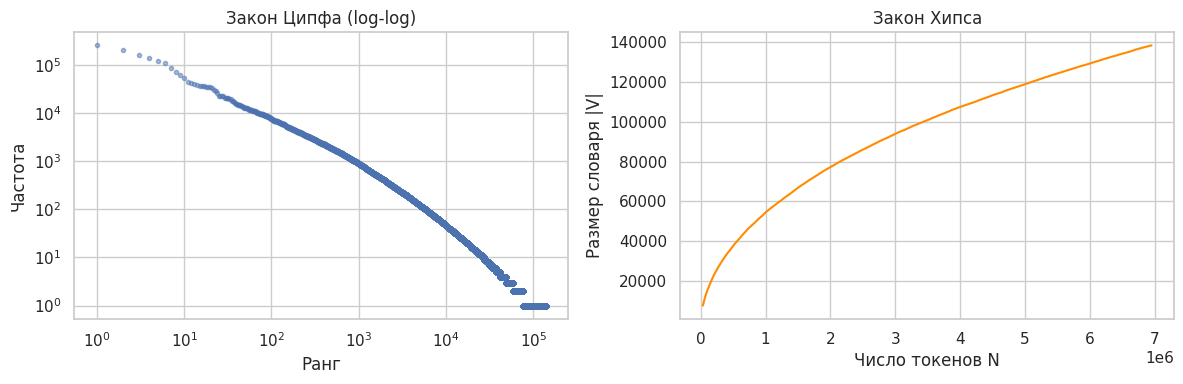

Оценка Хипса: K ≈ 47.45, b ≈ 0.508


In [ ]:
# Закон Ципфа: ранг vs частота (по токенам подвыборки)
word_counts = Counter(all_tokens)
freqs = np.array(sorted(word_counts.values(), reverse=True), dtype=float)
ranks = np.arange(1, len(freqs) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(ranks, freqs, marker=".", linestyle="none", alpha=0.5)
axes[0].set_xlabel("Ранг")
axes[0].set_ylabel("Частота")
axes[0].set_title("Закон Ципфа (log-log)")

# Закон Хипса: накопление уникальных типов
unique = set()
heap_n: list[int] = []
heap_v: list[int] = []
step = max(1, len(all_tokens) // 200)

for i, tok in enumerate(all_tokens, start=1):
    unique.add(tok)
    if i % step == 0 or i == len(all_tokens):
        heap_n.append(i)
        heap_v.append(len(unique))

axes[1].plot(heap_n, heap_v, color="darkorange")
axes[1].set_xlabel("Число токенов N")
axes[1].set_ylabel("Размер словаря |V|")
axes[1].set_title("Закон Хипса")

plt.tight_layout()
plt.show()

# Грубая оценка параметров Хипса: log|V| = log K + b log N
log_n = np.log(heap_n)
log_v = np.log(heap_v)
b, log_k = np.polyfit(log_n, log_v, 1)
print(f"Оценка Хипса: K ≈ {np.exp(log_k):.2f}, b ≈ {b:.3f}")


### 5. Частоты отдельных слов

Считаем по **леммам** на подвыборке.


In [ ]:
lemma_counts = Counter(all_lemmas)

employee = lemma_counts.get("сотрудник", 0)
client = lemma_counts.get("клиент", 0)
fraud = lemma_counts.get("мошенничество", 0)
trust = lemma_counts.get("доверие", 0)

print(f"сотрудник: {employee:,}")
print(f"клиент:    {client:,}")
print(
    "Чаще встречается:",
    "сотрудник" if employee > client else "клиент" if client > employee else "одинаково",
)
print(f"мошенничество: {fraud:,}")
print(f"доверие:       {trust:,}")


сотрудник: 26,354
клиент:    27,067
Чаще встречается: клиент
мошенничество: 693
доверие:       439


### 6. Ключевые слова и биграммы (tf-idf) для оценок 1 и 5


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


def top_tfidf_terms(
    texts: list[str],
    ngram_range: tuple[int, int] = (1, 1),
    top_k: int = 20,
) -> pd.DataFrame:
    """Средний tf-idf по корпусу → топ признаков."""
    vectorizer = TfidfVectorizer(
        tokenizer=tokenize,
        preprocessor=None,
        lowercase=False,
        ngram_range=ngram_range,
        min_df=5,
        max_df=0.9,
        stop_words=list(RU_STOPWORDS),
    )
    matrix = vectorizer.fit_transform(texts)
    mean_scores = np.asarray(matrix.mean(axis=0)).ravel()
    terms = np.array(vectorizer.get_feature_names_out())
    order = mean_scores.argsort()[::-1][:top_k]
    return pd.DataFrame({"term": terms[order], "mean_tfidf": mean_scores[order]})


pos_texts = df.loc[df["rating_grade"] == 5, "text"].tolist()
neg_texts = df.loc[df["rating_grade"] == 1, "text"].tolist()
print(f"Положительных (5): {len(pos_texts):,}, отрицательных (1): {len(neg_texts):,}")

# Чтобы tf-idf считался быстрее — сэмпл с каждой стороны
N_TFIDF = 8_000
rng = np.random.default_rng(0)
pos_sample = list(rng.choice(pos_texts, size=min(N_TFIDF, len(pos_texts)), replace=False))
neg_sample = list(rng.choice(neg_texts, size=min(N_TFIDF, len(neg_texts)), replace=False))

print("\n--- Униграммы: оценка 5 ---")
display(top_tfidf_terms(pos_sample, (1, 1)))
print("--- Униграммы: оценка 1 ---")
display(top_tfidf_terms(neg_sample, (1, 1)))

print("\n--- Биграммы: оценка 5 ---")
display(top_tfidf_terms(pos_sample, (2, 2)))
print("--- Биграммы: оценка 1 ---")
display(top_tfidf_terms(neg_sample, (2, 2)))


Положительных (5): 14,713, отрицательных (1): 47,387

--- Униграммы: оценка 5 ---


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,term,mean_tfidf
0,банка,0.035427
1,банк,0.030931
2,кредит,0.019907
3,карту,0.019768
4,деньги,0.019663
5,банке,0.018278
6,вклад,0.017673
7,спасибо,0.017101
8,карты,0.016881
9,быстро,0.015979


--- Униграммы: оценка 1 ---


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,term,mean_tfidf
0,интернет банк,0.009619
1,следующий день,0.007956
2,являюсь клиентом,0.007362
3,клиентом банка,0.006904
4,p s,0.006674
5,добрый день,0.006645
6,т д,0.006288
7,других банках,0.005825
8,хочу выразить,0.005781
9,большое спасибо,0.005618


--- Биграммы: оценка 1 ---


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,term,mean_tfidf
0,т е,0.008461
1,сих пор,0.007871
2,отделение банка,0.007258
3,добрый день,0.007058
4,следующий день,0.006713
5,денежных средств,0.006482
6,денежные средства,0.006360
7,сотрудник банка,0.006019
8,сотрудники банка,0.005868
9,горячую линию,0.005465


## Часть 2. Тематическое моделирование

Строим LSI/LDA (gensim) на лемматизированной подвыборке с разным числом тем.


In [ ]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.4 MB/s eta 0:00:00


In [ ]:
from gensim.corpora import Dictionary
from gensim.models import LsiModel, TfidfModel
from gensim.models.ldamulticore import LdaMulticore


def prepare_lemma_docs(texts: pd.Series) -> list[list[str]]:
    """Документы как списки лемм без стоп-слов (только длина >= 2)."""
    docs = []
    for text in tqdm(texts, desc="lemma docs"):
        lemmas = []
        for tok in tokenize(text):
            if tok in RU_STOPWORDS or len(tok) < 2:
                continue
            lemma = morph.parse(tok)[0].normal_form
            if lemma not in RU_STOPWORDS and len(lemma) >= 2:
                lemmas.append(lemma)
        if lemmas:
            docs.append(lemmas)
    return docs


# Для тем — чуть меньше документов, иначе LDA очень долгая
TOPIC_SAMPLE = min(12_000, len(df_sample))
topic_texts = df_sample["text"].sample(TOPIC_SAMPLE, random_state=42)
lemma_docs = prepare_lemma_docs(topic_texts)

dictionary = Dictionary(lemma_docs)
dictionary.filter_extremes(no_below=10, no_above=0.5)
bow_corpus = [dictionary.doc2bow(doc) for doc in lemma_docs]
tfidf_model = TfidfModel(bow_corpus)
tfidf_corpus = tfidf_model[bow_corpus]

print(f"Документов: {len(lemma_docs):,}, словарь: {len(dictionary):,}")


lemma docs:   0%|          | 0/12000 [00:00<?, ?it/s]

Документов: 12,000, словарь: 7,288


In [ ]:
def show_topics_pretty(model, n_topics: int | None = None, n_words: int = 10) -> None:
    topics = model.show_topics(num_topics=n_topics, num_words=n_words, formatted=False)
    for topic_id, words in topics:
        terms = ", ".join(w for w, _ in words)
        print(f"Тема {topic_id:02d}: {terms}")


print("=== LSI, 5 тем ===")
lsi_5 = LsiModel(corpus=tfidf_corpus, id2word=dictionary, num_topics=5)
show_topics_pretty(lsi_5, 5)

print("\n=== LSI, 15 тем ===")
lsi_15 = LsiModel(corpus=tfidf_corpus, id2word=dictionary, num_topics=15)
show_topics_pretty(lsi_15, 15)


=== LSI, 5 тем ===
Тема 00: карта, кредит, деньга, счёт, банкомат, заявление, отделение, вклад, сумма, сбербанк
Тема 01: вклад, кредит, очередь, открыть, платёж, задолженность, звонок, погашение, офис, кредитный
Тема 02: банкомат, кредит, вклад, карта, сбербанк, деньга, договор, страховка, операция, средство
Тема 03: вклад, сумма, заявка, руб, договор, номер, банкомат, рубль, погашение, процент
Тема 04: банкомат, карта, купюра, кредит, смс, вклад, деньга, очередь, страховка, интернет

=== LSI, 15 тем ===
Тема 00: карта, кредит, деньга, счёт, банкомат, заявление, отделение, вклад, сумма, сбербанк
Тема 01: вклад, кредит, очередь, платёж, открыть, задолженность, звонок, погашение, офис, кредитный
Тема 02: банкомат, кредит, вклад, карта, сбербанк, деньга, договор, страховка, операция, средство
Тема 03: вклад, сумма, заявка, руб, договор, номер, банкомат, погашение, рубль, процент
Тема 04: банкомат, карта, купюра, кредит, смс, вклад, страховка, деньга, очередь, интернет
Тема 05: номер, карт

In [ ]:
print("=== LDA, 10 тем ===")
lda_10 = LdaMulticore(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=10,
    passes=5,
    workers=2,
    random_state=42,
)
show_topics_pretty(lda_10, 10)

print("\n=== LDA, 20 тем ===")
lda_20 = LdaMulticore(
    corpus=bow_corpus,
    id2word=dictionary,
    num_topics=20,
    passes=5,
    workers=2,
    random_state=42,
)
show_topics_pretty(lda_20, 20)


=== LDA, 10 тем ===
Тема 00: очередь, клиент, сотрудник, кассир, касса, человек, отделение, время, окно, работать
Тема 01: карта, заявление, счёт, средство, операция, денежный, ответ, претензия, сотрудник, деньга
Тема 02: кредит, сумма, платёж, кредитный, год, договор, задолженность, месяц, погашение, сотрудник
Тема 03: отделение, заявление, деньга, сотрудник, сбербанк, ответ, договор, написать, получить, счёт
Тема 04: деньга, счёт, сбербанк, перевод, платёж, карта, сумма, операция, номер, рубль
Тема 05: вклад, сказать, документ, заявка, сотрудник, деньга, вопрос, позвонить, говорить, кредит
Тема 06: банкомат, деньга, карта, счёт, снять, клиент, купюра, сумма, наличный, операция
Тема 07: карта, отделение, кредитный, год, сказать, счёт, деньга, получить, мочь, обслуживание
Тема 08: клиент, номер, сотрудник, звонок, телефон, звонить, человек, работа, являться, вопрос
Тема 09: вклад, отделение, клиент, офис, очередь, время, минута, работать, деньга, девушка

=== LDA, 20 тем ===
Тема 00: с

### Темы с упоминанием конкретных банков

Ищем темы, в топ-словах которых есть сбербанк / втб / тинькофф и т.п.


In [ ]:
BANK_MARKERS = {
    "сбербанк", "сбер", "втб", "тинькофф", "альфабанк", "альфа", "райффайзен",
    "газпромбанк", "открытие", "хоумкредит", "ренессанс", "югра", "бинбанк",
}


def topics_with_banks(model, markers=BANK_MARKERS, topn: int = 25) -> None:
    topics = model.show_topics(num_topics=-1, num_words=topn, formatted=False)
    found = False
    for topic_id, words in topics:
        terms = [w for w, _ in words]
        hits = [t for t in terms if any(m in t for m in markers)]
        if hits:
            found = True
            print(f"Тема {topic_id:02d} | банки: {hits}")
            print("  ", ", ".join(terms[:15]))
    if not found:
        print("Явных банк-маркеров в топ-словах не нашлось — смотрите темы вручную.")


print("LDA-20 и банки:")
topics_with_banks(lda_20)

print("\nРаспределение банков в исходных данных (доля):")
print(df["bank_name"].value_counts(normalize=True).head(10))


LDA-20 и банки:
Тема 00 | банки: ['сбербанк']
   сбербанк, очередь, окно, квитанция, оплатить, платёж, филиал, терминал, отделение, оплата, человек, клиент, время, пенсия, сотрудник
Тема 03 | банки: ['сбербанк']
   отделение, заявление, деньга, сбербанк, сотрудник, сказать, написать, ответ, претензия, получить, позвонить, счёт, мочь, вопрос, обратиться
Тема 04 | банки: ['сбербанк']
   деньга, сбербанк, счёт, перевод, карта, номер, онлайн, платёж, мочь, операция, перевести, мобильный, услуга, смс, телефон
Тема 06 | банки: ['альфа']
   банкомат, деньга, карта, счёт, операция, снять, сумма, чек, выдать, рубль, наличный, претензия, средство, заявление, вернуть
Тема 10 | банки: ['открытие']
   вклад, деньга, договор, процент, открыть, доверенность, вкладчик, ставка, срок, год, клиент, получить, условие, время, депозит
Тема 11 | банки: ['сбербанк']
   документ, квартира, сказать, тыс, ипотека, кредит, неделя, взнос, заявка, сделка, ипотечный, машина, срок, автомобиль, сбербанк

Распределение

**Комментарий:** темы с именем банка часто смешивают бренд и продукт
(карта, кредит, вклад, отделение). Это ожидаемо: в отзывах банк упоминается
рядом с конкретной услугой, а не как отдельная «абстрактная» тема.


## Часть 3. Классификация текстов

Бинарная задача: оценка **1** vs **5**.


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# N1 / N2 — на усмотрение; берём сбалансированную выборку
N1 = N2 = 7_000
neg_pool = df.loc[df["rating_grade"] == 1, "text"]
pos_pool = df.loc[df["rating_grade"] == 5, "text"]

n1 = min(N1, len(neg_pool))
n2 = min(N2, len(pos_pool))

clf_df = pd.concat(
    [
        pd.DataFrame({"text": neg_pool.sample(n1, random_state=42), "label": 0}),
        pd.DataFrame({"text": pos_pool.sample(n2, random_state=42), "label": 1}),
    ],
    ignore_index=True,
).sample(frac=1.0, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    clf_df["text"],
    clf_df["label"],
    test_size=0.25,
    random_state=42,
    stratify=clf_df["label"],
)

print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")
print("Баланс train:\n", y_train.value_counts())


Train: 10,500, Test: 3,500
Баланс train:
 label
0    5250
1    5250
Name: count, dtype: int64


In [ ]:
def evaluate_pipeline(name: str, pipe: Pipeline) -> dict:
    """Обучаем пайплайн и считаем accuracy / F1."""
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred),
    }
    print(f"\n=== {name} ===")
    print(f"accuracy={metrics['accuracy']:.4f}, f1={metrics['f1']:.4f}")
    print(classification_report(y_test, pred, digits=3))
    return metrics


results: list[dict] = []

# Baseline: логистическая регрессия + разные векторизации
vectorizer_variants = {
    "unigrams": dict(analyzer="word", ngram_range=(1, 1), min_df=3, max_features=50_000),
    "word_bi/trigrams": dict(analyzer="word", ngram_range=(1, 3), min_df=3, max_features=80_000),
    "char_4-6grams": dict(analyzer="char", ngram_range=(4, 6), min_df=3, max_features=80_000),
}

for name, vect_params in vectorizer_variants.items():
    pipe = Pipeline(
        [
            ("vect", TfidfVectorizer(**vect_params)),
            (
                "clf",
                LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
            ),
        ]
    )
    results.append(evaluate_pipeline(f"baseline / {name}", pipe))



=== baseline / unigrams ===
accuracy=0.9494, f1=0.9488
              precision    recall  f1-score   support

           0      0.939     0.961     0.950      1750
           1      0.960     0.938     0.949      1750

    accuracy                          0.949      3500
   macro avg      0.950     0.949     0.949      3500
weighted avg      0.950     0.949     0.949      3500


=== baseline / word_bi/trigrams ===
accuracy=0.9491, f1=0.9484
              precision    recall  f1-score   support

           0      0.937     0.963     0.950      1750
           1      0.962     0.935     0.948      1750

    accuracy                          0.949      3500
   macro avg      0.949     0.949     0.949      3500
weighted avg      0.949     0.949     0.949      3500


=== baseline / char_4-6grams ===
accuracy=0.9534, f1=0.9527
              precision    recall  f1-score   support

           0      0.940     0.969     0.954      1750
           1      0.968     0.938     0.953      1750

 

In [ ]:
# Вариант 1: Count → tf-idf → TruncatedSVD (LSA) → классификатор
pipe_lsa = Pipeline(
    [
        ("vect", CountVectorizer(min_df=3, max_features=40_000)),
        ("tfidf", TfidfTransformer()),
        ("tm", TruncatedSVD(n_components=120, random_state=42)),
        (
            "clf",
            LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42),
        ),
    ]
)
results.append(evaluate_pipeline("tf-idf + TruncatedSVD (LSA)", pipe_lsa))

# Вариант 2: Count → LDA → классификатор
# LDA на полной матрице тяжёлая — ограничиваем словарь и число тем
pipe_lda = Pipeline(
    [
        ("vect", CountVectorizer(min_df=5, max_features=8_000)),
        (
            "tm",
            LatentDirichletAllocation(
                n_components=30,
                learning_method="batch",
                max_iter=10,
                random_state=42,
                n_jobs=-1,
            ),
        ),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)
results.append(evaluate_pipeline("LDA topics + RandomForest", pipe_lda))



=== tf-idf + TruncatedSVD (LSA) ===
accuracy=0.9326, f1=0.9318
              precision    recall  f1-score   support

           0      0.923     0.944     0.933      1750
           1      0.943     0.921     0.932      1750

    accuracy                          0.933      3500
   macro avg      0.933     0.933     0.933      3500
weighted avg      0.933     0.933     0.933      3500


=== LDA topics + RandomForest ===
accuracy=0.9049, f1=0.9040
              precision    recall  f1-score   support

           0      0.898     0.914     0.906      1750
           1      0.912     0.896     0.904      1750

    accuracy                          0.905      3500
   macro avg      0.905     0.905     0.905      3500
weighted avg      0.905     0.905     0.905      3500



,model,accuracy,f1
2,baseline / char_4-6grams,0.953429,0.952713
0,baseline / unigrams,0.949429,0.948829
1,baseline / word_bi/trigrams,0.949143,0.948436
3,tf-idf + TruncatedSVD (LSA),0.932571,0.931792
4,LDA topics + RandomForest,0.904857,0.904007


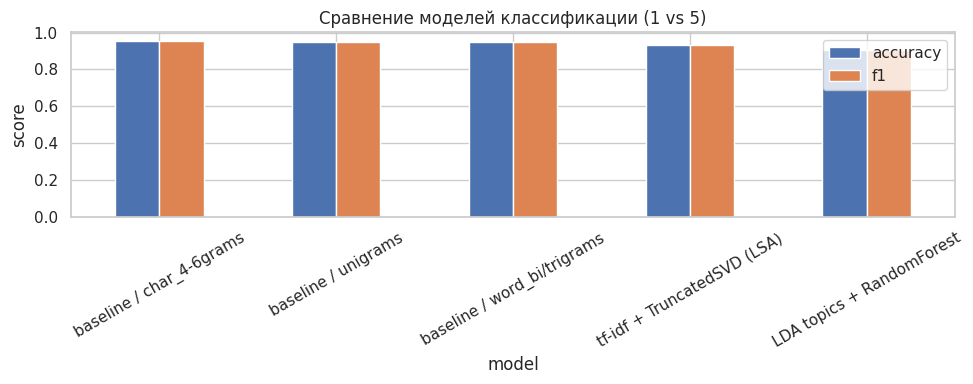

In [ ]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False)
display(results_df)

ax = results_df.plot(
    x="model",
    y=["accuracy", "f1"],
    kind="bar",
    figsize=(10, 4),
    rot=30,
)
ax.set_ylabel("score")
ax.set_title("Сравнение моделей классификации (1 vs 5)")
plt.tight_layout()
plt.show()


### Краткие выводы

1. **Анализ:** отзывы сильно смещены к крупным городам и банкам; длины текстов типично «длиннохвостые».
2. **Темы:** LSI/LDA выделяют продуктовые кластеры (карты, кредиты, вклады, обслуживание); имена банков всплывают внутри продуктовых тем.
3. **Классификация:** сильный baseline на tf-idf + LR; скрытые темы (LSA/LDA) дают компактные признаки, но не всегда бьют простой bag-of-n-grams на этой задаче.
